### This notebook focuses on interpreting the trained machine learning models using SHAP (SHapley Additive Explanations). It analyses feature importance and the direction of feature effects to understand the key drivers of airline disruption risk. 

# Imports

In [13]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## Redefine Numeric and Categorical Features

In [15]:
# Define the numeric features for modeling
numeric_features = [
    'lag_1_pct_disrupted', 'lag_2_pct_disrupted', 'lag_3_pct_disrupted',
    'lag_1_pct_cancelled', 'lag_2_pct_cancelled', 'lag_3_pct_cancelled',
    'lag_1_pct_diverted', 'lag_2_pct_diverted', 'lag_3_pct_diverted',
    'lag_1_avg_dep_delay', 'lag_2_avg_dep_delay', 'lag_3_avg_dep_delay',
    'lag_1_avg_arr_delay', 'lag_2_avg_arr_delay', 'lag_3_avg_arr_delay',
    'delta_pct_disrupted', 'delta_pct_cancelled', 'delta_pct_diverted',
    'delta_avg_dep_delay', 'delta_avg_arr_delay', 'delta2_pct_disrupted', 
    'delta2_pct_cancelled', 'delta2_avg_arr_delay','rolling_3_pct_disrupted', 
    'rolling_3_pct_cancelled', 'rolling_3_avg_dep_delay', 'rolling_3_avg_arr_delay',
    'rolling_3_std_pct_disrupted', 'rolling_3_std_pct_cancelled',
    'rolling_3_std_avg_dep_delay', 'rolling_3_std_avg_arr_delay',
    'lag_1_total_scheduled_flights', 'lag_2_total_scheduled_flights',
    'lag_3_total_scheduled_flights', 'delta_total_scheduled_flights',
    'rolling_3_total_scheduled_flights', 'rolling_3_std_total_scheduled_flights',
    'airline_prev_pct_disrupted', 'airline_prev_pct_cancelled', 'airport_prev_pct_disrupted',
    'airport_prev_pct_cancelled', 'interaction_disruption_delay', 'interaction_disruption_cancel',
    'interaction_volume_delay', 'month_num', 'quarter'
]

# Define the categorical features for modeling
categorical_features = [
    'Reporting_Airline',
    'Origin'
]

# Define the target column
target_col = 'HighDisruptionMonth'

# Display the feature groups
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Target column:", target_col)

Numeric features: ['lag_1_pct_disrupted', 'lag_2_pct_disrupted', 'lag_3_pct_disrupted', 'lag_1_pct_cancelled', 'lag_2_pct_cancelled', 'lag_3_pct_cancelled', 'lag_1_pct_diverted', 'lag_2_pct_diverted', 'lag_3_pct_diverted', 'lag_1_avg_dep_delay', 'lag_2_avg_dep_delay', 'lag_3_avg_dep_delay', 'lag_1_avg_arr_delay', 'lag_2_avg_arr_delay', 'lag_3_avg_arr_delay', 'delta_pct_disrupted', 'delta_pct_cancelled', 'delta_pct_diverted', 'delta_avg_dep_delay', 'delta_avg_arr_delay', 'delta2_pct_disrupted', 'delta2_pct_cancelled', 'delta2_avg_arr_delay', 'rolling_3_pct_disrupted', 'rolling_3_pct_cancelled', 'rolling_3_avg_dep_delay', 'rolling_3_avg_arr_delay', 'rolling_3_std_pct_disrupted', 'rolling_3_std_pct_cancelled', 'rolling_3_std_avg_dep_delay', 'rolling_3_std_avg_arr_delay', 'lag_1_total_scheduled_flights', 'lag_2_total_scheduled_flights', 'lag_3_total_scheduled_flights', 'delta_total_scheduled_flights', 'rolling_3_total_scheduled_flights', 'rolling_3_std_total_scheduled_flights', 'airline_pr

## Recreating the Processor

In [16]:
# Create a preprocessing pipeline for numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create a preprocessing pipeline for categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine numeric and categorical preprocessing steps
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Load Dataset

In [22]:
# Load the final modeling dataset
final_model_df = pd.read_parquet("../data/processed/final_modeling_data.parquet")

# Preview the dataset
final_model_df.head()

,lag_1_pct_disrupted,lag_2_pct_disrupted,lag_3_pct_disrupted,lag_1_pct_cancelled,lag_2_pct_cancelled,lag_3_pct_cancelled,lag_1_pct_diverted,lag_2_pct_diverted,lag_3_pct_diverted,lag_1_avg_dep_delay,...,airport_prev_pct_cancelled,interaction_disruption_delay,interaction_disruption_cancel,interaction_volume_delay,month_num,quarter,Reporting_Airline,Origin,HighDisruptionMonth,YearMonth
0,0.209302,0.044776,0.133333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.802326,...,0.000000,-0.051109,0.000000,-21.000000,7,3,9E,ABE,0,2023-07-01
1,0.164706,0.209302,0.044776,0.011628,0.000000,0.000000,0.000000,0.000000,0.000000,10.894118,...,0.011628,1.195571,0.001915,624.258824,8,3,9E,ABE,0,2023-08-01
2,0.220930,0.164706,0.209302,0.022472,0.011628,0.000000,0.011236,0.000000,0.000000,21.290698,...,0.022472,3.429557,0.004965,1381.569767,9,3,9E,ABE,0,2023-09-01
3,0.100000,0.220930,0.164706,0.000000,0.022472,0.011628,0.000000,0.011236,0.000000,5.062500,...,0.000000,-0.325000,0.000000,-260.000000,10,4,9E,ABE,0,2023-10-01
4,0.034884,0.100000,0.220930,0.000000,0.000000,0.022472,0.000000,0.000000,0.011236,-3.988372,...,0.000000,-0.693213,0.000000,-1709.000000,11,4,9E,ABE,0,2023-11-01


# Split Data into Train and Test Splits

In [21]:
# Create time-based training and test sets
train_df = final_model_df[final_model_df['YearMonth'] < '2025-01-01'].copy()
test_df = final_model_df[final_model_df['YearMonth'] >= '2025-01-01'].copy()

# Display the shapes of the training and test sets
print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Training set shape: (31975, 50)
Test set shape: (17600, 50)


# Recreate x and y

In [23]:
# Create training and test feature matrices
X_train = train_df[numeric_features + categorical_features].copy()
X_test = test_df[numeric_features + categorical_features].copy()

# Create training and test target vectors
y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

# Display the shapes of the feature matrices
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (31975, 48)
X_test shape: (17600, 48)


# For LightGBM

## Rebuilding the LightGBM Pipeline

In [26]:
# Create the LightGBM modeling pipeline
lgbm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        class_weight='balanced',
        random_state=42
    ))
])

# Fit the LightGBM model
lgbm_pipeline.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 7246, number of negative: 24729
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008967 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11918
[LightGBM] [Info] Number of data points in the train set: 31975, number of used features: 386
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Prepare Data for SHAP

In [53]:
# Extract preprocessor and model from pipeline
preprocessor_lgbm = lgbm_pipeline.named_steps['preprocessor']
lgbm_model = lgbm_pipeline.named_steps['model']

# Transform test data
X_test_transformed = preprocessor_lgbm.transform(X_test)

# Convert to dense
X_test_transformed = X_test_transformed.toarray()

# Get feature names
feature_names = preprocessor_lgbm.get_feature_names_out()

## SHAP Values

In [45]:
# Create explainer
explainer = shap.Explainer(lgbm_model)

# Compute SHAP values
shap_values = explainer(X_test_transformed)

## Summary Plot

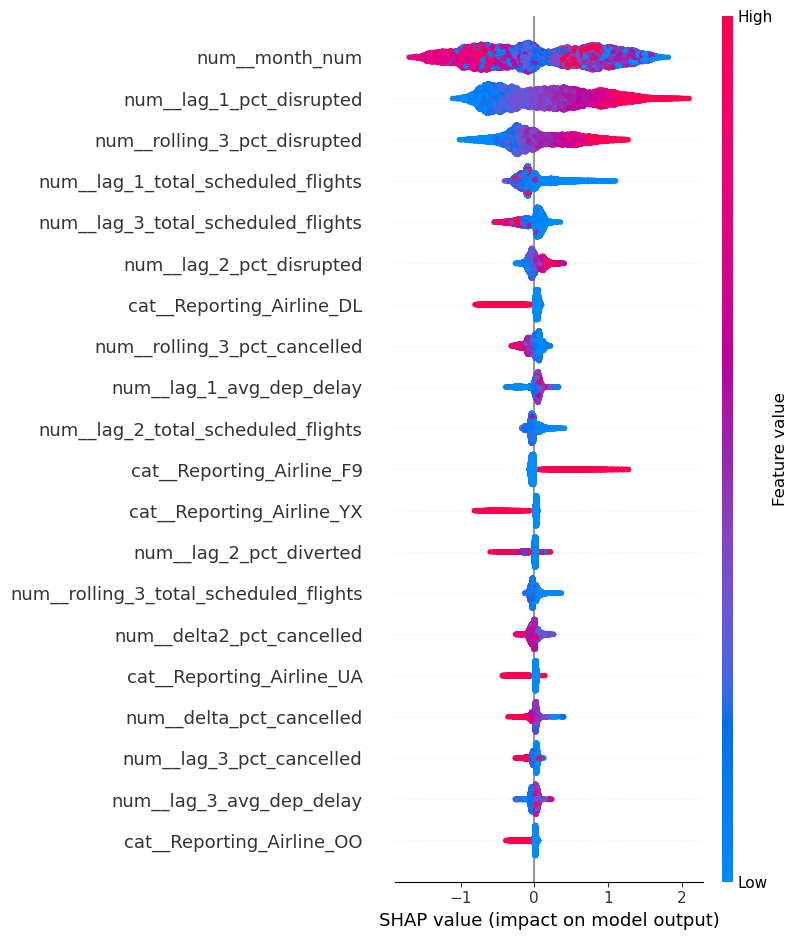

In [46]:
shap.summary_plot(
    shap_values,   
    X_test_transformed,
    feature_names=feature_names
)

# Bar Plot

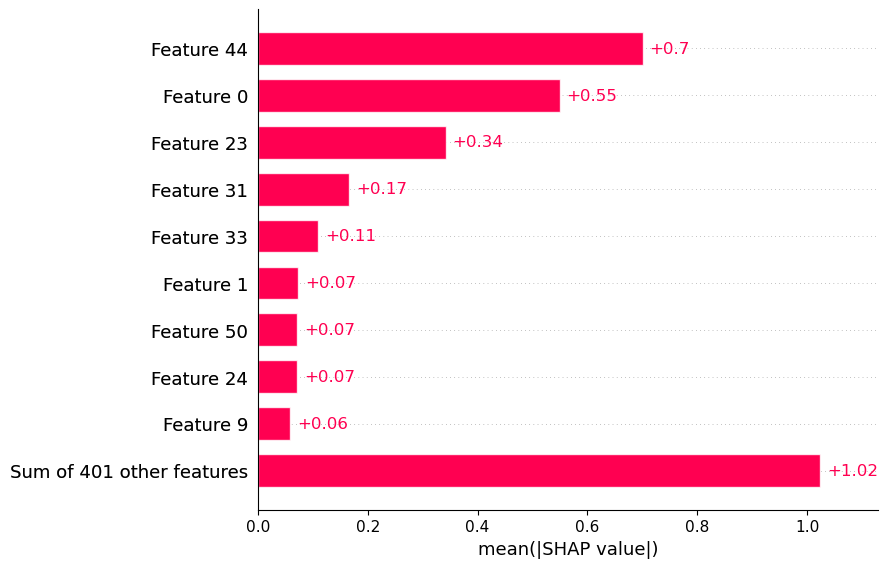

In [66]:
shap.plots.bar(shap_values)

## Save SHAP Plot

In [50]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, show=False)
plt.savefig("../reports/figures/shap_lgbm_summary.png", dpi=300, bbox_inches='tight')
plt.close()